# Stellar Coordinate Explorer - Colour by Magnitude (Random Sample)

## Objective
Create a scatter plot of the random sample where each source's colour represents its G-band magnitude (brightness). Fainter sources appear dimmer (or redder), brighter sources appear more luminous (or bluer).

## Why This Matters
Encoding a third dimension (magnitude) using colour reveals correlations between position and brightness.

## Dataset
- Input: `sources_with_galactic_coord_random.fits` (random sample with Galactic coordinates)
- Columns: `ra`, `dec`, `phot_g_mean_mag`

## Goals for Today
- Load the random sample.
- Create a scatter plot (Dec vs RA) with colour mapped to `phot_g_mean_mag`.
- Choose an appropriate colormap.
- Add a colourbar with label.
- Apply both linear and log stretch to the colour mapping. Log stretch will help better distinguish the fainter sources.

## Checkpoint
- Table loaded successfully
- Scatter plot with colour mapping generated
- Colourbar present and labelled ("G-band magnitude")
- Plot title includes number of sources
- List brief observations made from the plot

## Code 
### 1. Setup and Loading

In [1]:
# Import
from astropy.table import Table
import matplotlib.pyplot as plt
import numpy as np


# Load the randomly selected sources
table_rand = Table.read('../../data/sources_with_galactic_coord_random.fits')

table_rand.info()

<Table length=10000>
      name       dtype  unit    class     n_bad
--------------- ------- ---- ------------ -----
      source_id   int64            Column     0
             ra float64  deg       Column     0
            dec float64  deg       Column     0
          gal_l float64  deg       Column     0
          gal_b float64  deg       Column     0
       parallax float64  mas       Column     0
phot_g_mean_mag float32  mag       Column     0
          bp_rp float32  mag MaskedColumn    12


### 2. Showcasing Magnitude Variation through Plotting

We now add the scatter plot with magnitude-based colour-mapping using both linear and log stretching:

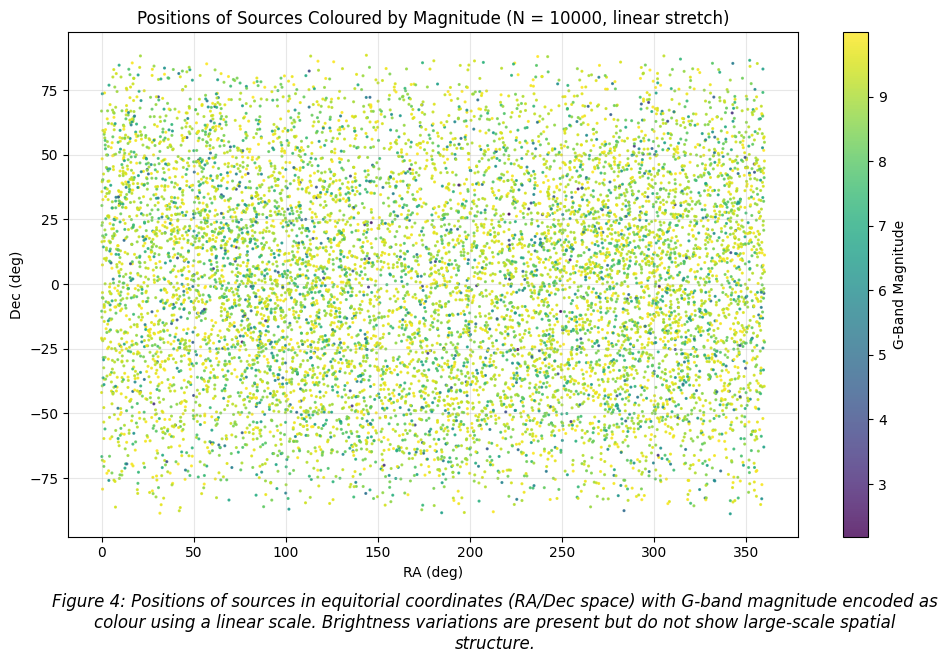

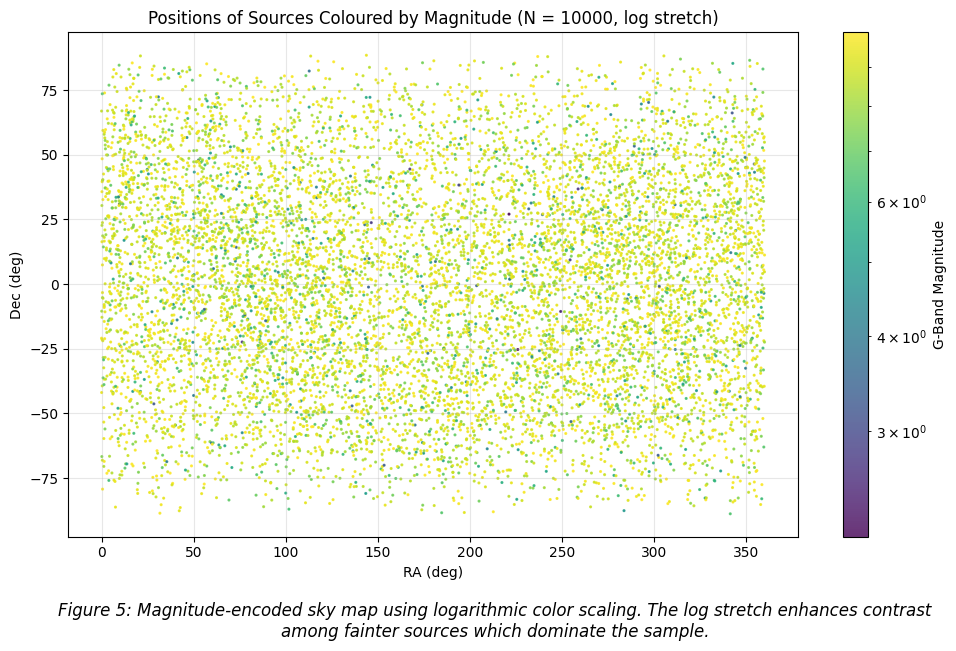

In [2]:
from astropy.visualization import MinMaxInterval
import textwrap


# Get the min and max magnitudes
interval = MinMaxInterval()
min_G_mag, max_G_mag = interval.get_limits(table_rand['phot_g_mean_mag'])


# Scatter Plot with Linear Stretch Magnitude Normalization

plt.figure(figsize=(10, 6))
sc = plt.scatter(table_rand['ra'], table_rand['dec'],  c=table_rand['phot_g_mean_mag'], vmin=min_G_mag, vmax=max_G_mag, norm='linear', cmap='viridis', s=1.5, alpha=0.8)    
plt.colorbar(sc, label='G-Band Magnitude')
plt.title(f'Positions of Sources Coloured by Magnitude (N = {len(table_rand)}, linear stretch)')
plt.xlabel('RA (deg)')
plt.ylabel('Dec (deg)')
plt.grid(True, alpha=0.3) 

# Caption
fig_caption = """Figure 4: Positions of sources in equitorial coordinates (RA/Dec space) with G-band magnitude encoded as colour using a linear scale.
Brightness variations are present but do not show large-scale spatial structure."""
wrapper = textwrap.TextWrapper(width=107)
lines = wrapper.wrap(text=fig_caption)
fig_caption_wrapped = '\n'.join(lines)

plt.tight_layout()
plt.figtext(0.5, -0.09, fig_caption_wrapped, ha='center', fontsize=12, style='italic')
plt.savefig('../../outputs/random_sample_mag_colour_linear-stretch.png', dpi=300, bbox_inches='tight')
plt.show()


# Scatter Plot with Log Stretch Magnitude Normalization

plt.figure(figsize=(10, 6))
sc = plt.scatter(table_rand['ra'], table_rand['dec'],  c=table_rand['phot_g_mean_mag'], vmin=min_G_mag, vmax=max_G_mag, norm='log', cmap='viridis', s=1.5, alpha=0.8)    
plt.colorbar(sc, label='G-Band Magnitude')
plt.title(f'Positions of Sources Coloured by Magnitude (N = {len(table_rand)}, log stretch)')
plt.xlabel('RA (deg)')
plt.ylabel('Dec (deg)')
plt.grid(True, alpha=0.3) 

# Caption
fig_caption = """Figure 5: Magnitude-encoded sky map using logarithmic color scaling. The log stretch enhances contrast among fainter sources which
dominate the sample."""
wrapper = textwrap.TextWrapper(width=106)
lines = wrapper.wrap(text=fig_caption)
fig_caption_wrapped = '\n'.join(lines)

plt.tight_layout()
plt.figtext(0.5, -0.07, fig_caption_wrapped, ha='center', fontsize=12, style='italic')
plt.savefig('../../outputs/random_sample_mag_colour_log-stretch.png', dpi=300, bbox_inches='tight')
plt.show()



The scatter plots appear saturated, making it hard to observe meaningful distributions. Therefore we use a hexbin plot to reduce visual noise by obtaining the median magnitude in each hexagonal bin:

In [1]:
# Hexbin Plot with Linear Stretch Magnitude Normalization

plt.figure(figsize=(10, 6))
hb = plt.hexbin(table_rand['ra'], table_rand['dec'], C=table_rand['phot_g_mean_mag'], norm='linear', gridsize=100, cmap='viridis', reduce_C_function=np.median)
plt.colorbar(hb, label='Median G magnitude')
plt.xlabel('RA (deg)')
plt.ylabel('Dec (deg)')
plt.title('Median Magnitude per Hexbin (N = 10000, linear stretch)')

# Caption
fig_caption = """Figure 6: Hexbin visualization of median linear-stretched stellar magnitudes across the Ra/Dec sky. Aggregation accentuates subtle
spatial trends in brightness distribution while minimizing visual noise."""
wrapper = textwrap.TextWrapper(width=105)
lines = wrapper.wrap(text=fig_caption)
fig_caption_wrapped = '\n'.join(lines)

plt.tight_layout()
plt.figtext(0.5, -0.05, fig_caption_wrapped, ha='center', fontsize=12, style='italic')
plt.savefig('../../outputs/random_sample_hexbin_mag_colour_linear-stretch.png', dpi=300, bbox_inches='tight')
plt.show()


# Hexbin Plot with Log Stretch Magnitude Normalization
plt.figure(figsize=(10, 6))
hb = plt.hexbin(table_rand['ra'], table_rand['dec'], C=table_rand['phot_g_mean_mag'], norm='log', gridsize=100, cmap='viridis', reduce_C_function=np.median)
plt.colorbar(hb, label='Median G magnitude')
plt.xlabel('RA (deg)')
plt.ylabel('Dec (deg)')
plt.title('Median Magnitude per Hexbin (N = 10000, log stretch)')

# Caption
fig_caption = """Figure 7: Hexbin map showing the median log-stretched stellar magnitude per spatial bin. Aggregation reduces visual noise and
highlights subtle spatial trends in brightness distribution."""
wrapper = textwrap.TextWrapper(width=105)
lines = wrapper.wrap(text=fig_caption)
fig_caption_wrapped = '\n'.join(lines)

plt.tight_layout()
plt.figtext(0.5, -0.05, fig_caption_wrapped, ha='center', fontsize=12, style='italic')
plt.savefig('../../outputs/random_sample_hexbin_mag_colour_log-stretch.png', dpi=300, bbox_inches='tight')
plt.show()

NameError: name 'plt' is not defined

## Observations

- Both linear and logarithmic colour scales show relatively uniform magnitude distributions across the sky with only subtle variations.
- The logarithmic stretching enhances the visibility of fainter sources which appear to dominate the dataset.

## Interpretation
Unlike stellar density which is determined by the Milky Way structure, stellar brightness does not exhibit strong spatial patterns in this sample. This is because magnitude depends on a number of factors including distance and intrinsic luminosity, hence the mixed distribution.
